Toy Measurement Control Initialized


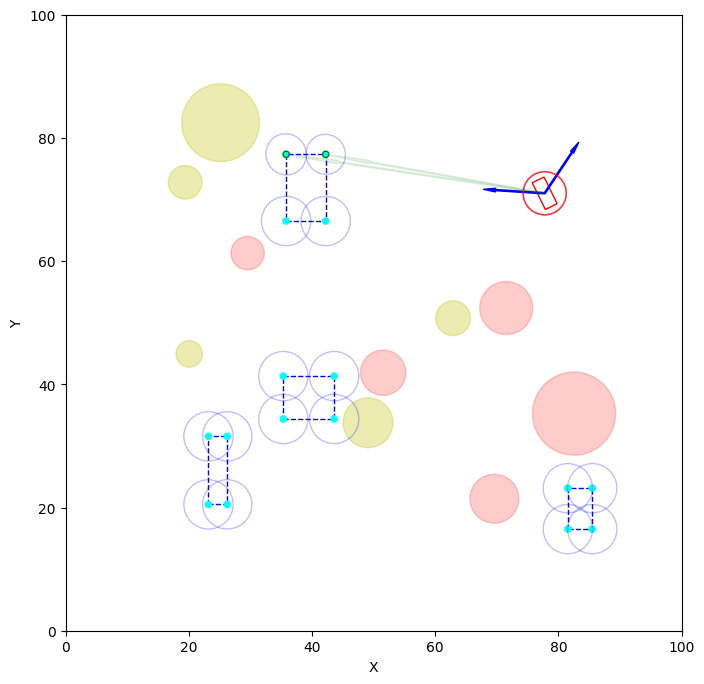

In [48]:
import numpy as np
import pandas as pd
import timeit
import sys
import multiprocessing as mp
from copy import deepcopy
from functools import partial
import matplotlib.pyplot as plt
# Add measurement mcts python package to path
sys.path.append('../../src/measurement_mcts')
from measurement_mcts.mcts.mcts import mcts_search, get_best_trajectory, MCTSNode, DummyNode
from measurement_mcts.mcts.tree_viz import render_pyvis
from measurement_mcts.state_evaluation.reinforcement_learning import MCTSRLWrapper, plot_state_image
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment

# Create the environment
enable_explore_grid = False
env = MeasurementControlEnvironment(init_reset=False, enable_explore_grid=enable_explore_grid)

env.load_state('../../state_configurations', 'evaluation2')

env.draw_state(env.get_state(), plot_explore_grid=enable_explore_grid)
starting_state = env.get_state()

Simulating 100 steps, for a total of 10.0 seconds
Time taken for  0.1 : 0.007704354999077623
Simulating 50 steps, for a total of 10.0 seconds
Time taken for  0.2 : 0.001446913000108907
Simulating 25 steps, for a total of 10.0 seconds
Time taken for  0.4 : 0.0007125530009943759
Simulating 16 steps, for a total of 9.6 seconds
Time taken for  0.6 : 0.0004998839995096205
Simulating 10 steps, for a total of 10 seconds
Time taken for  1 : 0.00036310300129116513


(0.0, 100.0)

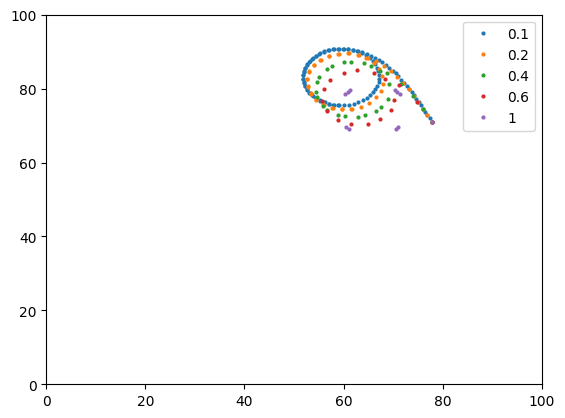

In [41]:
def car_update_at_dt(starting_state, dt):
    car_state = starting_state[0]
    car_states = [car_state]

    time = 10 # seconds
    # dt = 0.1 # seconds
    steps = int(time/dt)
    print(f'Simulating {steps} steps, for a total of {steps*dt} seconds')
    start_time = timeit.default_timer()
    for i in range(int(time/dt)):
        car_state = env.car.update(dt, [1., .1], starting_state=car_state)
        car_states.append(deepcopy(car_state))
        
    print('Time taken for ', dt, ':', timeit.default_timer() - start_time)
    
    return car_states

starting_state[0][2] = 10
env.car.max_velocity = 10

car_states_01 = np.array(car_update_at_dt(starting_state, 0.1))
car_states_02 = np.array(car_update_at_dt(starting_state, 0.2))
car_states_04 = np.array(car_update_at_dt(starting_state, 0.4))
car_states_05 = np.array(car_update_at_dt(starting_state, 0.6))
car_states_1 = np.array(car_update_at_dt(starting_state, 1))

# Plot the x and y values of the car
fig, ax = plt.subplots()

ax.plot(car_states_01[:, 0], car_states_01[:, 1], 'o', markersize=2, label='0.1')
ax.plot(car_states_02[:, 0], car_states_02[:, 1], 'o', markersize=2, label='0.2')
ax.plot(car_states_04[:, 0], car_states_04[:, 1], 'o', markersize=2, label='0.4')
ax.plot(car_states_05[:, 0], car_states_05[:, 1], 'o', markersize=2, label='0.6')
ax.plot(car_states_1[:, 0], car_states_1[:, 1], 'o', markersize=2, label='1')

ax.legend()

# # figure to x and y [0, 100]
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])

In [70]:
env.horizon_length = 30
def collision_occlusion_check(car_state):
    # Now see if the car has collided with any objects in the object manager
    objects_in_collision_df = env.object_manager.check_collision(car_state)
    
    # Get an observation from the object manager at this new car state
    observation_dict, new_object_df = env.object_manager.get_observation(car_state, df=object_df)
    
    return objects_in_collision_df, observation_dict, new_object_df

car_state = starting_state[0]
car_states = []
object_df = starting_state[1]
depth = starting_state[3]
action = [1, 0.1]
future_steps = env.horizon_length - depth + 1

start_time = timeit.default_timer()
for i in range(future_steps):
    car_state = env.car.update(env.simulation_dt, action, starting_state=car_state)
    car_states.append(deepcopy(car_state))


# Check collision and get observation in parallel
pool = mp.Pool(processes=future_steps)
results = pool.map(collision_occlusion_check, car_states)

pool.close()
pool.join()

objects_in_collision_dfs, observation_dicts, new_object_dfs  = zip(*results)

# Now apply all observations to the object manager
for i in range(future_steps):
    # Apply the observation and get sum of the trace differences and the new object dataframe
    new_object_df, trace_delta_sum = env.apply_observation(observation_dicts[i], new_object_dfs[i], car_states[i])

print('Time taken for ', future_steps, 'updates:', timeit.default_timer() - start_time)

# fig, ax = plt.subplots()
# ax.plot(car_states_01[:, 0], car_states_01[:, 1], 'o', markersize=2, label='0.1')
# # limit plot to x and y [0, 100]
# ax.set_xlim([0, 100])
# ax.set_ylim([0, 100])

Time taken for  31 updates: 0.22750905200155103


In [72]:
state = starting_state
start_time = timeit.default_timer()
for i in range(future_steps):
    state, reward, done = env.step(state, action)
print('Time taken for ', future_steps, 'updates:', timeit.default_timer() - start_time)

Time taken for  31 updates: 0.117912753001292


## Well there you have it, single rollout parallelism is not helpful :(